# 01 — EDA, Data Structure Check & Relationship Audit

**Vai trò của notebook này**

Notebook này tập trung vào **khảo sát dữ liệu (EDA)** và **kiểm tra cấu trúc dữ liệu** cho bộ Olist trước khi modeling. Mục tiêu chính:

1. Đọc và khảo sát **đủ 9 bảng CSV**.
2. Kiểm tra kích thước, kiểu dữ liệu, missing values, duplicate, khóa join và coverage quan hệ giữa các bảng.
3. Vẽ **ERD logic** ở mức notebook để phục vụ báo cáo.
4. Tạo một **order-level EDA base** đi qua đủ 9 bảng nhằm hỗ trợ:
   - phân tích hành vi mua hàng,
   - xu hướng theo thời gian,
   - review / giao hàng / địa lý / danh mục,
   - RFM mô tả.
5. Sinh **insight mô tả**, không train model và không tạo dependency mới cho các notebook sau.

**Nguyên tắc tương thích**
- Notebook này **không đổi tên file nào** và **không ghi đè artifact lõi** mà notebook khác đang dùng.
- Mọi bảng/figure trong notebook này chỉ phục vụ **EDA, báo cáo và kiểm tra logic dữ liệu**.


## Cell 1 — Import thư viện

Cell này import các thư viện cần cho EDA:
- `pandas`, `numpy` để xử lý dữ liệu;
- `matplotlib` để vẽ biểu đồ và ERD logic;
- `display`, `Markdown` để trình bày kết quả rõ ràng trong notebook.


In [1]:
from pathlib import Path
import json

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from IPython.display import display, Markdown


## Cell 2 — Khai báo danh sách file raw và hàm resolve đường dẫn

Cell này giúp notebook tự tìm đúng thư mục `data/raw` trên nhiều môi trường khác nhau.

Mục đích:
- tránh hard-code một đường dẫn cố định;
- giúp notebook chạy ổn định hơn khi mở từ Jupyter, VS Code hoặc thư mục project khác nhau.


In [2]:
RAW_FILENAMES = {
    "customers": "olist_customers_dataset.csv",
    "geolocation": "olist_geolocation_dataset.csv",
    "order_items": "olist_order_items_dataset.csv",
    "order_payments": "olist_order_payments_dataset.csv",
    "order_reviews": "olist_order_reviews_dataset.csv",
    "orders": "olist_orders_dataset.csv",
    "products": "olist_products_dataset.csv",
    "sellers": "olist_sellers_dataset.csv",
    "category_translation": "product_category_name_translation.csv",
}

def resolve_project_paths():
    candidates = [
        Path.cwd(),
        Path.cwd().parent,
        Path.cwd().parent.parent,
        Path("."),
        Path(".."),
        Path("../.."),
    ]

    checked = []
    for base in candidates:
        base = base.resolve()
        raw_dir = base / "data" / "raw"
        checked.append(str(raw_dir))
        if raw_dir.exists() and all((raw_dir / fname).exists() for fname in RAW_FILENAMES.values()):
            return base, raw_dir

    raise FileNotFoundError(
        "Không tìm thấy thư mục data/raw chứa đủ 9 file CSV bắt buộc.\n"
        + "Các path đã kiểm tra:\n- "
        + "\n- ".join(checked)
    )


## Cell 3 — Resolve `BASE_DIR` và `RAW_DIR`

Cell này chạy hàm resolve và in ra path đang dùng để:
- minh bạch môi trường chạy;
- hỗ trợ debug khi notebook không tìm được data.


In [3]:
BASE_DIR, RAW_DIR = resolve_project_paths()

print("BASE_DIR:", BASE_DIR)
print("RAW_DIR :", RAW_DIR)


BASE_DIR: C:\Users\trant\OneDrive\Tài liệu\Documents\UTE\BIGDATA\olist_ml_project
RAW_DIR : C:\Users\trant\OneDrive\Tài liệu\Documents\UTE\BIGDATA\olist_ml_project\data\raw


## Cell 4 — Đọc đủ 9 bảng CSV

Cell này load toàn bộ 9 bảng của bộ dữ liệu Olist để bảo đảm notebook EDA bám sát dataset gốc.


In [4]:
customers = pd.read_csv(RAW_DIR / RAW_FILENAMES["customers"])
geolocation = pd.read_csv(RAW_DIR / RAW_FILENAMES["geolocation"])
order_items = pd.read_csv(RAW_DIR / RAW_FILENAMES["order_items"])
order_payments = pd.read_csv(RAW_DIR / RAW_FILENAMES["order_payments"])
order_reviews = pd.read_csv(RAW_DIR / RAW_FILENAMES["order_reviews"])
orders = pd.read_csv(RAW_DIR / RAW_FILENAMES["orders"])
products = pd.read_csv(RAW_DIR / RAW_FILENAMES["products"])
sellers = pd.read_csv(RAW_DIR / RAW_FILENAMES["sellers"])
category_translation = pd.read_csv(RAW_DIR / RAW_FILENAMES["category_translation"])


## Cell 5 — Bảng tổng quan kích thước 9 bảng

Cell này tạo bảng kích thước dữ liệu ban đầu để điền trực tiếp vào báo cáo phần tổng quan dataset.


In [5]:
raw_table_summary = pd.DataFrame({
    "table": list(RAW_FILENAMES.keys()),
    "file_name": list(RAW_FILENAMES.values()),
    "rows": [
        len(customers), len(geolocation), len(order_items), len(order_payments),
        len(order_reviews), len(orders), len(products), len(sellers), len(category_translation)
    ],
    "cols": [
        customers.shape[1], geolocation.shape[1], order_items.shape[1], order_payments.shape[1],
        order_reviews.shape[1], orders.shape[1], products.shape[1], sellers.shape[1], category_translation.shape[1]
    ]
})

display(raw_table_summary)


,table,file_name,rows,cols
0,customers,olist_customers_dataset.csv,99441,5
1,geolocation,olist_geolocation_dataset.csv,1000163,5
2,order_items,olist_order_items_dataset.csv,112650,7
3,order_payments,olist_order_payments_dataset.csv,103886,5
4,order_reviews,olist_order_reviews_dataset.csv,99224,7
5,orders,olist_orders_dataset.csv,99441,8
6,products,olist_products_dataset.csv,32951,9
7,sellers,olist_sellers_dataset.csv,3095,4
8,category_translation,product_category_name_translation.csv,71,2


## Cell 6 — Tạo từ điển DataFrame để thao tác nhất quán

Cell này gom các bảng vào một dictionary `dfs` để:
- lặp qua các bảng dễ hơn;
- giảm code lặp ở các bước thống kê phía sau.


In [6]:
dfs = {
    "customers": customers.copy(),
    "geolocation": geolocation.copy(),
    "order_items": order_items.copy(),
    "order_payments": order_payments.copy(),
    "order_reviews": order_reviews.copy(),
    "orders": orders.copy(),
    "products": products.copy(),
    "sellers": sellers.copy(),
    "category_translation": category_translation.copy(),
}


## Cell 7 — Xem tổng quát nhanh từng bảng

Cell này hiển thị 3 thông tin quan trọng cho từng bảng:
- shape,
- số cột,
- tên cột.

Mục đích:
- giúp rà nhanh schema trước khi đi vào join và kiểm tra quan hệ.


In [7]:
overview_rows = []
for name, df in dfs.items():
    overview_rows.append({
        "table": name,
        "shape": str(df.shape),
        "n_cols": df.shape[1],
        "columns": ", ".join(df.columns.tolist())
    })

overview_df = pd.DataFrame(overview_rows)
display(overview_df)


,table,shape,n_cols,columns
0,customers,"(99441, 5)",5,"customer_id, customer_unique_id, customer_zip_..."
1,geolocation,"(1000163, 5)",5,"geolocation_zip_code_prefix, geolocation_lat, ..."
2,order_items,"(112650, 7)",7,"order_id, order_item_id, product_id, seller_id..."
3,order_payments,"(103886, 5)",5,"order_id, payment_sequential, payment_type, pa..."
4,order_reviews,"(99224, 7)",7,"review_id, order_id, review_score, review_comm..."
5,orders,"(99441, 8)",8,"order_id, customer_id, order_status, order_pur..."
6,products,"(32951, 9)",9,"product_id, product_category_name, product_nam..."
7,sellers,"(3095, 4)",4,"seller_id, seller_zip_code_prefix, seller_city..."
8,category_translation,"(71, 2)",2,"product_category_name, product_category_name_e..."


## Cell 8 — Kiểm tra `.info()` ở mức tóm tắt cho từng bảng

Cell này tạo bảng summary về:
- số cột numeric / object / datetime;
- số dòng;
- bộ nhớ ước lượng.

Mục tiêu là thay cho việc in `.info()` quá dài nhưng vẫn giữ được thông tin cốt lõi cho EDA.


In [8]:
dtype_summary_rows = []
for name, df in dfs.items():
    dtype_counts = df.dtypes.astype(str).value_counts().to_dict()
    dtype_summary_rows.append({
        "table": name,
        "rows": len(df),
        "cols": df.shape[1],
        "memory_mb_est": round(df.memory_usage(deep=True).sum() / (1024**2), 2),
        "dtype_breakdown": json.dumps(dtype_counts, ensure_ascii=False),
    })

dtype_summary_df = pd.DataFrame(dtype_summary_rows)
display(dtype_summary_df)


,table,rows,cols,memory_mb_est,dtype_breakdown
0,customers,99441,5,29.62,"{""object"": 4, ""int64"": 1}"
1,geolocation,1000163,5,145.20,"{""float64"": 2, ""object"": 2, ""int64"": 1}"
2,order_items,112650,7,39.43,"{""object"": 4, ""float64"": 2, ""int64"": 1}"
3,order_payments,103886,5,17.81,"{""object"": 2, ""int64"": 2, ""float64"": 1}"
4,order_reviews,99224,7,42.75,"{""object"": 6, ""int64"": 1}"
5,orders,99441,8,58.97,"{""object"": 8}"
6,products,32951,9,6.79,"{""float64"": 7, ""object"": 2}"
7,sellers,3095,4,0.66,"{""object"": 3, ""int64"": 1}"
8,category_translation,71,2,0.01,"{""object"": 2}"


## Cell 9 — Mô tả logic quan hệ giữa các bảng

Cell này tạo bảng quan hệ logic giữa 9 bảng Olist:
- bảng nào nối với bảng nào,
- join key là gì,
- cardinality gần đúng ra sao,
- vai trò business là gì.

Đây là phần thay cho phần thuyết minh ERD trong báo cáo.


In [9]:
relationship_df = pd.DataFrame([
    {"left_table": "orders", "right_table": "customers", "join_key": "customer_id", "cardinality": "N:1", "business_meaning": "Mỗi đơn hàng thuộc về một khách hàng"},
    {"left_table": "orders", "right_table": "order_items", "join_key": "order_id", "cardinality": "1:N", "business_meaning": "Một đơn hàng có thể có nhiều item"},
    {"left_table": "orders", "right_table": "order_payments", "join_key": "order_id", "cardinality": "1:N", "business_meaning": "Một đơn hàng có thể có nhiều record thanh toán"},
    {"left_table": "orders", "right_table": "order_reviews", "join_key": "order_id", "cardinality": "1:1 hoặc 1:N", "business_meaning": "Một đơn hàng có thể có review"},
    {"left_table": "order_items", "right_table": "products", "join_key": "product_id", "cardinality": "N:1", "business_meaning": "Mỗi item tham chiếu đến một sản phẩm"},
    {"left_table": "order_items", "right_table": "sellers", "join_key": "seller_id", "cardinality": "N:1", "business_meaning": "Mỗi item do một seller cung cấp"},
    {"left_table": "products", "right_table": "category_translation", "join_key": "product_category_name", "cardinality": "N:1", "business_meaning": "Dịch category sang tiếng Anh"},
    {"left_table": "customers", "right_table": "geolocation", "join_key": "zip prefix", "cardinality": "N:1 gần đúng", "business_meaning": "Bổ sung thông tin địa lý khách hàng"},
    {"left_table": "sellers", "right_table": "geolocation", "join_key": "zip prefix", "cardinality": "N:1 gần đúng", "business_meaning": "Bổ sung thông tin địa lý người bán"},
])

display(relationship_df)


,left_table,right_table,join_key,cardinality,business_meaning
0,orders,customers,customer_id,N:1,Mỗi đơn hàng thuộc về một khách hàng
1,orders,order_items,order_id,1:N,Một đơn hàng có thể có nhiều item
2,orders,order_payments,order_id,1:N,Một đơn hàng có thể có nhiều record thanh toán
3,orders,order_reviews,order_id,1:1 hoặc 1:N,Một đơn hàng có thể có review
4,order_items,products,product_id,N:1,Mỗi item tham chiếu đến một sản phẩm
5,order_items,sellers,seller_id,N:1,Mỗi item do một seller cung cấp
6,products,category_translation,product_category_name,N:1,Dịch category sang tiếng Anh
7,customers,geolocation,zip prefix,N:1 gần đúng,Bổ sung thông tin địa lý khách hàng
8,sellers,geolocation,zip prefix,N:1 gần đúng,Bổ sung thông tin địa lý người bán


## Cell 10 — Vẽ ERD logic ở mức notebook

Cell này dùng `matplotlib` để vẽ sơ đồ quan hệ logic giữa 9 bảng.
- Đây không phải ERD database chuẩn mức enterprise,
- nhưng đủ để minh họa mối quan hệ dữ liệu và hỗ trợ chấm rubric phần ERD.


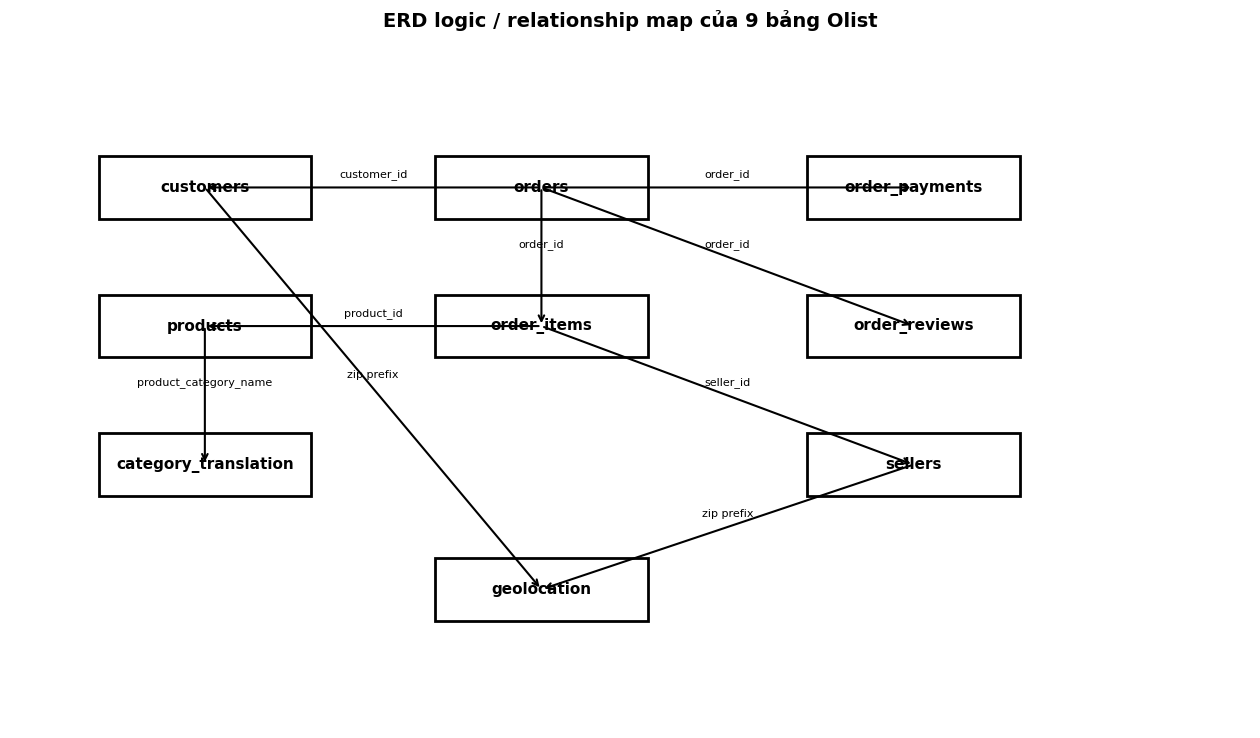

In [10]:
fig, ax = plt.subplots(figsize=(16, 9))
ax.set_xlim(0, 14)
ax.set_ylim(0, 10)
ax.axis("off")

boxes = {
    "orders": (6, 7.8),
    "customers": (2.2, 7.8),
    "order_items": (6, 5.8),
    "order_payments": (10.2, 7.8),
    "order_reviews": (10.2, 5.8),
    "products": (2.2, 5.8),
    "sellers": (10.2, 3.8),
    "category_translation": (2.2, 3.8),
    "geolocation": (6, 2.0),
}

for name, (x, y) in boxes.items():
    rect = plt.Rectangle((x-1.2, y-0.45), 2.4, 0.9, fill=False, linewidth=2)
    ax.add_patch(rect)
    ax.text(x, y, name, ha="center", va="center", fontsize=11, fontweight="bold")

arrows = [
    ("orders", "customers", "customer_id"),
    ("orders", "order_items", "order_id"),
    ("orders", "order_payments", "order_id"),
    ("orders", "order_reviews", "order_id"),
    ("order_items", "products", "product_id"),
    ("order_items", "sellers", "seller_id"),
    ("products", "category_translation", "product_category_name"),
    ("customers", "geolocation", "zip prefix"),
    ("sellers", "geolocation", "zip prefix"),
]

for src, dst, label in arrows:
    x1, y1 = boxes[src]
    x2, y2 = boxes[dst]
    ax.annotate("", xy=(x2, y2), xytext=(x1, y1),
                arrowprops=dict(arrowstyle="->", lw=1.5))
    ax.text((x1+x2)/2, (y1+y2)/2 + 0.15, label, fontsize=8, ha="center")

ax.set_title("ERD logic / relationship map của 9 bảng Olist", fontsize=14, fontweight="bold")
plt.show()


## Cell 11 — Chuẩn hóa cột thời gian và zip prefix

Cell này chuẩn hóa:
- các timestamp quan trọng về `datetime`;
- zip prefix của `customers / sellers / geolocation` về kiểu số nullable để join địa lý ổn định hơn.


In [11]:
for col in [
    "order_purchase_timestamp",
    "order_approved_at",
    "order_delivered_carrier_date",
    "order_delivered_customer_date",
    "order_estimated_delivery_date",
]:
    dfs["orders"][col] = pd.to_datetime(dfs["orders"][col], errors="coerce")

dfs["order_items"]["shipping_limit_date"] = pd.to_datetime(
    dfs["order_items"]["shipping_limit_date"], errors="coerce"
)

for col in ["review_creation_date", "review_answer_timestamp"]:
    dfs["order_reviews"][col] = pd.to_datetime(dfs["order_reviews"][col], errors="coerce")

for col in [("customers", "customer_zip_code_prefix"), ("sellers", "seller_zip_code_prefix"), ("geolocation", "geolocation_zip_code_prefix")]:
    table, c = col
    dfs[table][c] = pd.to_numeric(dfs[table][c], errors="coerce").astype("Int64")

display(pd.DataFrame({
    "table": ["orders", "order_items", "order_reviews"],
    "key_datetime_columns_converted": [
        "order_purchase_timestamp, order_approved_at, delivered_*",
        "shipping_limit_date",
        "review_creation_date, review_answer_timestamp",
    ]
}))


,table,key_datetime_columns_converted
0,orders,"order_purchase_timestamp, order_approved_at, d..."
1,order_items,shipping_limit_date
2,order_reviews,"review_creation_date, review_answer_timestamp"


## Cell 12 — Kiểm tra duplicate toàn dòng của các bảng

Cell này giúp xác định bảng nào có duplicate toàn dòng đáng kể.

Chính sách đọc kết quả:
- duplicate nhiều ở `geolocation` là bình thường hơn vì đây là bảng lookup vị trí;
- duplicate ở các bảng khóa nghiệp vụ cần được kiểm tra kỹ hơn.


In [12]:
dup_full_rows_df = pd.DataFrame({
    "table": list(dfs.keys()),
    "duplicate_full_rows": [df.duplicated().sum() for df in dfs.values()],
    "rows": [len(df) for df in dfs.values()],
})

display(dup_full_rows_df)


,table,duplicate_full_rows,rows
0,customers,0,99441
1,geolocation,261831,1000163
2,order_items,0,112650
3,order_payments,0,103886
4,order_reviews,0,99224
5,orders,0,99441
6,products,0,32951
7,sellers,0,3095
8,category_translation,0,71


## Cell 13 — Kiểm tra uniqueness của các khóa quan trọng

Cell này kiểm tra mức độ unique của các khóa business chính.

Ý nghĩa:
- giúp phát hiện sớm bảng nào có grain không như mong đợi;
- hỗ trợ giải thích cardinality trong báo cáo.


In [13]:
key_uniqueness_df = pd.DataFrame([
    {"table": "orders", "key_col": "order_id", "nunique": dfs["orders"]["order_id"].nunique(), "rows": len(dfs["orders"])},
    {"table": "customers", "key_col": "customer_id", "nunique": dfs["customers"]["customer_id"].nunique(), "rows": len(dfs["customers"])},
    {"table": "customers", "key_col": "customer_unique_id", "nunique": dfs["customers"]["customer_unique_id"].nunique(), "rows": len(dfs["customers"])},
    {"table": "products", "key_col": "product_id", "nunique": dfs["products"]["product_id"].nunique(), "rows": len(dfs["products"])},
    {"table": "sellers", "key_col": "seller_id", "nunique": dfs["sellers"]["seller_id"].nunique(), "rows": len(dfs["sellers"])},
    {"table": "order_items", "key_col": "order_id", "nunique": dfs["order_items"]["order_id"].nunique(), "rows": len(dfs["order_items"])},
    {"table": "order_payments", "key_col": "order_id", "nunique": dfs["order_payments"]["order_id"].nunique(), "rows": len(dfs["order_payments"])},
    {"table": "order_reviews", "key_col": "order_id", "nunique": dfs["order_reviews"]["order_id"].nunique(), "rows": len(dfs["order_reviews"])},
])

key_uniqueness_df["unique_ratio_pct"] = (key_uniqueness_df["nunique"] / key_uniqueness_df["rows"] * 100).round(2)
display(key_uniqueness_df)


,table,key_col,nunique,rows,unique_ratio_pct
0,orders,order_id,99441,99441,100.00
1,customers,customer_id,99441,99441,100.00
2,customers,customer_unique_id,96096,99441,96.64
3,products,product_id,32951,32951,100.00
4,sellers,seller_id,3095,3095,100.00
5,order_items,order_id,98666,112650,87.59
6,order_payments,order_id,99440,103886,95.72
7,order_reviews,order_id,98673,99224,99.44


## Cell 14 — Kiểm tra missing values theo từng bảng

Cell này gom lại số lượng và tỷ lệ missing của mọi bảng để xác định bảng nào cần đi sâu thêm.


In [14]:
missing_summary_rows = []
for name, df in dfs.items():
    missing_summary_rows.append({
        "table": name,
        "rows": len(df),
        "cols": df.shape[1],
        "total_missing_cells": int(df.isnull().sum().sum()),
        "missing_columns": int((df.isnull().sum() > 0).sum()),
    })

missing_table_summary_df = pd.DataFrame(missing_summary_rows).sort_values("total_missing_cells", ascending=False)
display(missing_table_summary_df)


,table,rows,cols,total_missing_cells,missing_columns
4,order_reviews,99224,7,145903,2
5,orders,99441,8,4908,3
6,products,32951,9,2448,8
0,customers,99441,5,0,0
1,geolocation,1000163,5,0,0
2,order_items,112650,7,0,0
3,order_payments,103886,5,0,0
7,sellers,3095,4,0,0
8,category_translation,71,2,0,0


## Cell 15 — Top cột missing quan trọng trong toàn dataset

Cell này bung chi tiết các cột missing lớn nhất để ưu tiên xử lý/giải thích.


In [15]:
global_missing_detail = []
for name, df in dfs.items():
    miss = df.isnull().sum()
    miss = miss[miss > 0]
    for col, count in miss.items():
        global_missing_detail.append({
            "table": name,
            "column": col,
            "missing_count": int(count),
            "missing_pct": round(count / len(df) * 100, 2),
        })

global_missing_detail_df = pd.DataFrame(global_missing_detail).sort_values(
    ["missing_pct", "missing_count"], ascending=[False, False]
).reset_index(drop=True)

display(global_missing_detail_df.head(25))


,table,column,missing_count,missing_pct
0,order_reviews,review_comment_title,87656,88.34
1,order_reviews,review_comment_message,58247,58.70
2,orders,order_delivered_customer_date,2965,2.98
3,products,product_category_name,610,1.85
4,products,product_name_lenght,610,1.85
5,products,product_description_lenght,610,1.85
6,products,product_photos_qty,610,1.85
7,orders,order_delivered_carrier_date,1783,1.79
8,orders,order_approved_at,160,0.16
9,products,product_weight_g,2,0.01


## Cell 16 — Biểu đồ top missing columns

Cell này trực quan hóa các cột thiếu dữ liệu mạnh nhất để phục vụ phần nhận xét EDA.


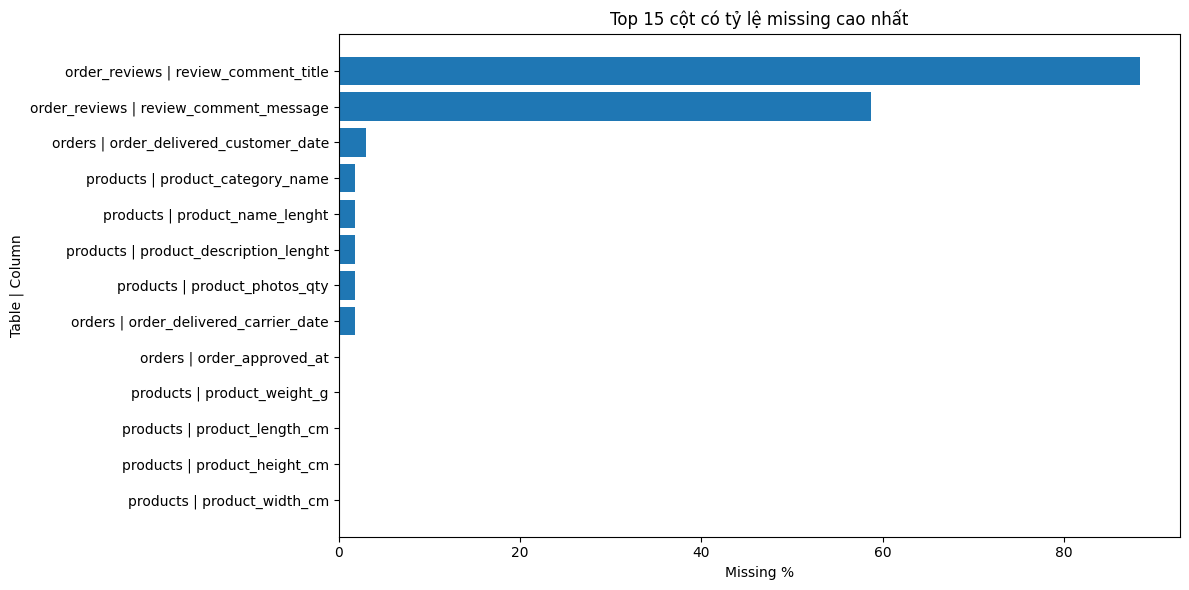

In [16]:
top_missing_plot_df = global_missing_detail_df.head(15).copy()

plt.figure(figsize=(12, 6))
plt.barh(top_missing_plot_df["table"] + " | " + top_missing_plot_df["column"], top_missing_plot_df["missing_pct"])
plt.gca().invert_yaxis()
plt.xlabel("Missing %")
plt.ylabel("Table | Column")
plt.title("Top 15 cột có tỷ lệ missing cao nhất")
plt.tight_layout()
plt.show()


## Cell 17 — Drill-down riêng các bảng missing quan trọng

Cell này tập trung vào 3 bảng thường gây ảnh hưởng mạnh nhất downstream:
- `order_reviews`
- `products`
- `orders`


In [17]:
for table_name in ["order_reviews", "products", "orders"]:
    display(Markdown(f"### Missing detail — `{table_name}`"))
    df = dfs[table_name]
    tmp = (
        df.isnull().sum()
        .reset_index()
        .rename(columns={"index": "column", 0: "missing_count"})
    )
    tmp["missing_pct"] = (tmp["missing_count"] / len(df) * 100).round(2)
    tmp = tmp[tmp["missing_count"] > 0].sort_values("missing_pct", ascending=False)
    display(tmp if not tmp.empty else pd.DataFrame({"message": [f"{table_name} không có missing"]}))


### Missing detail — `order_reviews`

,column,missing_count,missing_pct
3,review_comment_title,87656,88.34
4,review_comment_message,58247,58.70


### Missing detail — `products`

,column,missing_count,missing_pct
1,product_category_name,610,1.85
2,product_name_lenght,610,1.85
3,product_description_lenght,610,1.85
4,product_photos_qty,610,1.85
5,product_weight_g,2,0.01
6,product_length_cm,2,0.01
7,product_height_cm,2,0.01
8,product_width_cm,2,0.01


### Missing detail — `orders`

,column,missing_count,missing_pct
6,order_delivered_customer_date,2965,2.98
5,order_delivered_carrier_date,1783,1.79
4,order_approved_at,160,0.16


## Cell 18 — Kiểm tra coverage khóa join giữa các bảng

Cell này đo mức độ phủ khi nối các bảng chính:
- `orders -> customers`
- `order_items -> orders`
- `order_items -> products`
- `order_items -> sellers`
- `order_payments -> orders`
- `order_reviews -> orders`
- `products -> category_translation`


In [18]:
coverage_rows = []

coverage_rows.append({
    "left_table": "orders",
    "right_table": "customers",
    "join_key": "customer_id",
    "left_rows": len(dfs["orders"]),
    "matched_left_rows": int(dfs["orders"]["customer_id"].isin(dfs["customers"]["customer_id"]).sum()),
})

coverage_rows.append({
    "left_table": "order_items",
    "right_table": "orders",
    "join_key": "order_id",
    "left_rows": len(dfs["order_items"]),
    "matched_left_rows": int(dfs["order_items"]["order_id"].isin(dfs["orders"]["order_id"]).sum()),
})

coverage_rows.append({
    "left_table": "order_items",
    "right_table": "products",
    "join_key": "product_id",
    "left_rows": len(dfs["order_items"]),
    "matched_left_rows": int(dfs["order_items"]["product_id"].isin(dfs["products"]["product_id"]).sum()),
})

coverage_rows.append({
    "left_table": "order_items",
    "right_table": "sellers",
    "join_key": "seller_id",
    "left_rows": len(dfs["order_items"]),
    "matched_left_rows": int(dfs["order_items"]["seller_id"].isin(dfs["sellers"]["seller_id"]).sum()),
})

coverage_rows.append({
    "left_table": "order_payments",
    "right_table": "orders",
    "join_key": "order_id",
    "left_rows": len(dfs["order_payments"]),
    "matched_left_rows": int(dfs["order_payments"]["order_id"].isin(dfs["orders"]["order_id"]).sum()),
})

coverage_rows.append({
    "left_table": "order_reviews",
    "right_table": "orders",
    "join_key": "order_id",
    "left_rows": len(dfs["order_reviews"]),
    "matched_left_rows": int(dfs["order_reviews"]["order_id"].isin(dfs["orders"]["order_id"]).sum()),
})

coverage_rows.append({
    "left_table": "products",
    "right_table": "category_translation",
    "join_key": "product_category_name",
    "left_rows": int(dfs["products"]["product_category_name"].notna().sum()),
    "matched_left_rows": int(
        dfs["products"]["product_category_name"].dropna().isin(dfs["category_translation"]["product_category_name"]).sum()
    ),
})

coverage_df = pd.DataFrame(coverage_rows)
coverage_df["coverage_pct"] = (coverage_df["matched_left_rows"] / coverage_df["left_rows"] * 100).round(2)
display(coverage_df)


,left_table,right_table,join_key,left_rows,matched_left_rows,coverage_pct
0,orders,customers,customer_id,99441,99441,100.00
1,order_items,orders,order_id,112650,112650,100.00
2,order_items,products,product_id,112650,112650,100.00
3,order_items,sellers,seller_id,112650,112650,100.00
4,order_payments,orders,order_id,103886,103886,100.00
5,order_reviews,orders,order_id,99224,99224,100.00
6,products,category_translation,product_category_name,32341,32328,99.96


## Cell 19 — Chuẩn bị helper cho phần order-level EDA base

Cell này định nghĩa các helper dùng để:
- lấy mode an toàn;
- chuẩn hóa danh mục;
- chuẩn hóa zip prefix cho geolocation.


In [19]:
def safe_mode(series, default="unknown"):
    s = series.dropna()
    mode_vals = s.mode()
    return mode_vals.iloc[0] if not mode_vals.empty else default

def normalize_zip_prefix(series):
    return pd.to_numeric(series, errors="coerce").astype("Int64")


## Cell 20 — Tạo `geo_by_zip` để dùng geolocation vào EDA base

Cell này aggregate `geolocation` về mức `zip prefix` để:
- tránh nổ dòng;
- vẫn đi qua bảng `geolocation`;
- bổ sung feature địa lý gọn cho khách hàng và seller.


In [20]:
geo_df = dfs["geolocation"].drop_duplicates().copy()
geo_df["geolocation_zip_code_prefix"] = normalize_zip_prefix(geo_df["geolocation_zip_code_prefix"])

geo_by_zip = (
    geo_df
    .dropna(subset=["geolocation_zip_code_prefix"])
    .groupby("geolocation_zip_code_prefix", as_index=False)
    .agg(
        geo_lat_mean=("geolocation_lat", "mean"),
        geo_lng_mean=("geolocation_lng", "mean"),
        geo_city_mode=("geolocation_city", lambda x: safe_mode(x, default="unknown")),
        geo_state_mode=("geolocation_state", lambda x: safe_mode(x, default="unknown")),
        geo_record_count=("geolocation_lat", "size"),
    )
)

display(geo_by_zip.head())
print("geo_by_zip shape:", geo_by_zip.shape)


,geolocation_zip_code_prefix,geo_lat_mean,geo_lng_mean,geo_city_mode,geo_state_mode,geo_record_count
0,1001,-23.550227,-46.634039,sao paulo,SP,11
1,1002,-23.547657,-46.634991,sao paulo,SP,6
2,1003,-23.549000,-46.635582,sao paulo,SP,11
3,1004,-23.549829,-46.634792,sao paulo,SP,14
4,1005,-23.549547,-46.636406,sao paulo,SP,13


geo_by_zip shape: (19015, 6)


## Cell 21 — Tạo `products_en` và enrich `customers` / `sellers`

Cell này giúp order-level base của notebook EDA đi qua đủ 9 bảng:
- `products_en`: products + category_translation
- `customers_enriched`: customers + geolocation
- `sellers_enriched`: sellers + geolocation


In [21]:
products_en = (
    dfs["products"][["product_id", "product_category_name"]]
    .merge(dfs["category_translation"], on="product_category_name", how="left")
    .copy()
)

products_en["product_category_name_english"] = (
    products_en["product_category_name_english"]
    .fillna(products_en["product_category_name"])
    .fillna("unknown")
    .astype(str)
)

customers_enriched = dfs["customers"].copy()
customers_enriched["customer_zip_code_prefix"] = normalize_zip_prefix(customers_enriched["customer_zip_code_prefix"])
customers_enriched = customers_enriched.merge(
    geo_by_zip.add_prefix("customer_").rename(columns={"customer_geolocation_zip_code_prefix": "customer_zip_code_prefix"}),
    on="customer_zip_code_prefix",
    how="left",
)

sellers_enriched = dfs["sellers"].copy()
sellers_enriched["seller_zip_code_prefix"] = normalize_zip_prefix(sellers_enriched["seller_zip_code_prefix"])
sellers_enriched = sellers_enriched.merge(
    geo_by_zip.add_prefix("seller_").rename(columns={"seller_geolocation_zip_code_prefix": "seller_zip_code_prefix"}),
    on="seller_zip_code_prefix",
    how="left",
)

display(products_en.head())


,product_id,product_category_name,product_category_name_english
0,1e9e8ef04dbcff4541ed26657ea517e5,perfumaria,perfumery
1,3aa071139cb16b67ca9e5dea641aaa2f,artes,art
2,96bd76ec8810374ed1b65e291975717f,esporte_lazer,sports_leisure
3,cef67bcfe19066a932b7673e239eb23d,bebes,baby
4,9dc1a7de274444849c219cff195d0b71,utilidades_domesticas,housewares


## Cell 22 — Aggregate `order_items` ở mức đơn hàng có cả product/seller features

Cell này merge `order_items` với:
- `products_en`
- `sellers_enriched`

rồi aggregate về `order_id`.

Mục tiêu:
- tạo order-level view nhưng vẫn mang theo thông tin từ `products`, `category_translation`, `sellers`, `geolocation`.


In [22]:
items_tmp = (
    dfs["order_items"]
    .merge(products_en[["product_id", "product_category_name_english"]], on="product_id", how="left")
    .merge(
        sellers_enriched[[
            "seller_id",
            "seller_city",
            "seller_state",
            "seller_geo_lat_mean",
            "seller_geo_lng_mean",
        ]],
        on="seller_id",
        how="left",
    )
    .copy()
)

items_tmp["product_category_name_english"] = (
    items_tmp["product_category_name_english"].fillna("unknown").astype(str)
)

items_agg = (
    items_tmp
    .groupby("order_id", as_index=False)
    .agg(
        item_count=("order_item_id", "count"),
        unique_products=("product_id", "nunique"),
        unique_sellers=("seller_id", "nunique"),
        price_sum=("price", "sum"),
        freight_value_sum=("freight_value", "sum"),
        price_mean=("price", "mean"),
        main_category=("product_category_name_english", lambda x: safe_mode(x, default="unknown")),
        seller_city_mode=("seller_city", lambda x: safe_mode(x, default="unknown")),
        seller_state_mode=("seller_state", lambda x: safe_mode(x, default="unknown")),
        seller_geo_lat_mean=("seller_geo_lat_mean", "mean"),
        seller_geo_lng_mean=("seller_geo_lng_mean", "mean"),
    )
)

display(items_agg.head())
print("items_agg shape:", items_agg.shape)


,order_id,item_count,unique_products,unique_sellers,price_sum,freight_value_sum,price_mean,main_category,seller_city_mode,seller_state_mode,seller_geo_lat_mean,seller_geo_lng_mean
0,00010242fe8c5a6d1ba2dd792cb16214,1,1,1,58.90,13.29,58.90,cool_stuff,volta redonda,SP,-22.497188,-44.127324
1,00018f77f2f0320c557190d7a144bdd3,1,1,1,239.90,19.93,239.90,pet_shop,sao paulo,SP,-23.565754,-46.519097
2,000229ec398224ef6ca0657da4fc703e,1,1,1,199.00,17.87,199.00,furniture_decor,borda da mata,MG,-22.262802,-46.170735
3,00024acbcdf0a6daa1e931b038114c75,1,1,1,12.99,12.79,12.99,perfumery,franca,SP,-20.553651,-47.387145
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,1,1,199.90,18.14,199.90,garden_tools,loanda,PR,-22.929583,-53.135750


items_agg shape: (98666, 12)


## Cell 23 — Aggregate `order_payments` về mức đơn hàng

Cell này gom payment theo `order_id` để tránh nổ dòng khi merge.


In [23]:
payments_agg = (
    dfs["order_payments"]
    .groupby("order_id", as_index=False)
    .agg(
        payment_sequential_max=("payment_sequential", "max"),
        payment_installments_max=("payment_installments", "max"),
        payment_value_sum=("payment_value", "sum"),
        payment_type_mode=("payment_type", lambda x: safe_mode(x, default="unknown")),
    )
)

display(payments_agg.head())
print("payments_agg shape:", payments_agg.shape)


,order_id,payment_sequential_max,payment_installments_max,payment_value_sum,payment_type_mode
0,00010242fe8c5a6d1ba2dd792cb16214,1,2,72.19,credit_card
1,00018f77f2f0320c557190d7a144bdd3,1,3,259.83,credit_card
2,000229ec398224ef6ca0657da4fc703e,1,5,216.87,credit_card
3,00024acbcdf0a6daa1e931b038114c75,1,2,25.78,credit_card
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,3,218.04,credit_card


payments_agg shape: (99440, 5)


## Cell 24 — Aggregate `order_reviews` về mức đơn hàng

Cell này chuẩn hóa review text và aggregate review về `order_id`.


In [24]:
reviews_df = dfs["order_reviews"].copy()
reviews_df["review_comment_message"] = reviews_df["review_comment_message"].fillna("").astype(str)
reviews_df["review_comment_length"] = reviews_df["review_comment_message"].str.len()
reviews_df["has_comment"] = (reviews_df["review_comment_length"] > 0).astype("Int64")
reviews_df["review_response_hours"] = (
    reviews_df["review_answer_timestamp"] - reviews_df["review_creation_date"]
).dt.total_seconds() / 3600

reviews_df = reviews_df.sort_values(
    ["order_id", "review_creation_date", "review_answer_timestamp"], na_position="last"
)

reviews_agg = (
    reviews_df
    .groupby("order_id", as_index=False)
    .agg(
        review_count=("review_id", "count"),
        review_score=("review_score", "last"),
        review_comment_message=("review_comment_message", "last"),
        review_comment_length=("review_comment_length", "last"),
        has_comment=("has_comment", "max"),
        review_response_hours=("review_response_hours", "last"),
    )
)

display(reviews_agg.head())
print("reviews_agg shape:", reviews_agg.shape)


,order_id,review_count,review_score,review_comment_message,review_comment_length,has_comment,review_response_hours
0,00010242fe8c5a6d1ba2dd792cb16214,1,5,"Perfeito, produto entregue antes do combinado.",46,1,34.950833
1,00018f77f2f0320c557190d7a144bdd3,1,4,,0,0,59.570278
2,000229ec398224ef6ca0657da4fc703e,1,5,Chegou antes do prazo previsto e o produto sur...,90,1,16.108611
3,00024acbcdf0a6daa1e931b038114c75,1,4,,0,0,16.650278
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,5,Gostei pois veio no prazo determinado .,39,1,34.916389


reviews_agg shape: (98673, 7)


## Cell 25 — Tạo `orders_base_eda` đi qua đủ 9 bảng

Thứ tự merge:
1. `orders`
2. `customers_enriched`
3. `items_agg`
4. `payments_agg`
5. `reviews_agg`

Giải thích:
- `customers_enriched` đã mang geolocation của khách;
- `items_agg` đã mang products, category_translation, sellers và geolocation của seller.

Như vậy order-level EDA base này thực chất đã **đi qua đủ 9 bảng**, nhưng chỉ dùng cho khảo sát dữ liệu trong notebook 01.


In [25]:
orders_base_eda = (
    dfs["orders"]
    .merge(
        customers_enriched[[
            "customer_id", "customer_unique_id", "customer_city", "customer_state",
            "customer_zip_code_prefix", "customer_geo_lat_mean", "customer_geo_lng_mean"
        ]],
        on="customer_id",
        how="left",
    )
    .merge(items_agg, on="order_id", how="left")
    .merge(payments_agg, on="order_id", how="left")
    .merge(reviews_agg, on="order_id", how="left")
)

display(orders_base_eda.head())
print("orders_base_eda shape:", orders_base_eda.shape)


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_unique_id,customer_city,...,payment_sequential_max,payment_installments_max,payment_value_sum,payment_type_mode,review_count,review_score,review_comment_message,review_comment_length,has_comment,review_response_hours
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,7c396fd4830fd04220f754e42b4e5bff,sao paulo,...,3.0,1.0,38.71,voucher,1.0,4.0,"Não testei o produto ainda, mas ele veio corre...",170.0,1,27.730000
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,af07308b275d755c9edb36a90c618231,barreiras,...,1.0,1.0,141.46,boleto,1.0,4.0,Muito bom o produto.,20.0,1,18.630556
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,3a653a41f6f9fc3d2a113cf8398680e8,vianopolis,...,1.0,3.0,179.12,credit_card,1.0,5.0,,0.0,0,115.132778
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15,7c142cf63193a1473d2e66489a9ae977,sao goncalo do amarante,...,1.0,1.0,72.20,credit_card,1.0,5.0,O produto foi exatamente o que eu esperava e e...,105.0,1,67.366111
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26,72632f0f9dd73dfee390c9b22eb56dd6,santo andre,...,1.0,1.0,28.62,credit_card,1.0,5.0,,0.0,0,37.047500


orders_base_eda shape: (99441, 35)


## Cell 26 — Kiểm tra grain sau merge của `orders_base_eda`

Cell này xác nhận:
- số dòng của base;
- số lượng `order_id` unique;
- grain cuối có còn đúng `1 order = 1 row` hay không.


In [26]:
grain_audit_df = pd.DataFrame([{
    "orders_rows": len(dfs["orders"]),
    "orders_unique_order_id": dfs["orders"]["order_id"].nunique(),
    "orders_base_eda_rows": len(orders_base_eda),
    "orders_base_eda_unique_order_id": orders_base_eda["order_id"].nunique(),
    "orders_base_eda_order_id_is_unique": bool(orders_base_eda["order_id"].is_unique),
}])

display(grain_audit_df)


,orders_rows,orders_unique_order_id,orders_base_eda_rows,orders_base_eda_unique_order_id,orders_base_eda_order_id_is_unique
0,99441,99441,99441,99441,True


## Cell 27 — Missing values trên `orders_base_eda`

Cell này giúp xem sau khi join thành order-level base thì những cột nào còn thiếu dữ liệu đáng kể.


In [27]:
orders_base_missing_df = (
    orders_base_eda.isnull().sum()
    .reset_index()
    .rename(columns={"index": "column", 0: "missing_count"})
)

orders_base_missing_df["missing_pct"] = (
    orders_base_missing_df["missing_count"] / len(orders_base_eda) * 100
).round(2)

orders_base_missing_df = orders_base_missing_df.sort_values("missing_pct", ascending=False)
display(orders_base_missing_df.head(25))


,column,missing_count,missing_pct
6,order_delivered_customer_date,2965,2.98
5,order_delivered_carrier_date,1783,1.79
24,seller_geo_lng_mean,991,1.00
23,seller_geo_lat_mean,991,1.00
16,unique_sellers,775,0.78
15,unique_products,775,0.78
14,item_count,775,0.78
20,main_category,775,0.78
21,seller_city_mode,775,0.78
22,seller_state_mode,775,0.78


## Cell 28 — Xử lý missing tối thiểu để phục vụ EDA

Cell này **không làm preprocessing cuối cho modeling**, mà chỉ fill tối thiểu các cột cần cho EDA:
- text → chuỗi rỗng,
- categorical chính → `unknown`,
- count / binary → `0`.


In [28]:
orders_base_eda["review_comment_message"] = orders_base_eda["review_comment_message"].fillna("")

for col in ["main_category", "payment_type_mode", "customer_city", "customer_state", "seller_city_mode", "seller_state_mode"]:
    if col in orders_base_eda.columns:
        orders_base_eda[col] = orders_base_eda[col].fillna("unknown")

for col in ["review_count", "has_comment"]:
    if col in orders_base_eda.columns:
        orders_base_eda[col] = orders_base_eda[col].fillna(0)


## Cell 29 — Sinh feature thời gian, giao hàng và basket

Các feature này phục vụ EDA và là cầu nối logic sang notebook preprocessing/modeling:
- `approval_time_hours`
- `purchase_to_carrier_days`
- `delivery_time_days`
- `shipping_time_days`
- `delivery_delay_days`
- `basket_value`
- `purchase_year/month/day/hour/dayofweek`
- `is_late_delivery`


In [29]:
orders_base_eda["approval_time_hours"] = (
    orders_base_eda["order_approved_at"] - orders_base_eda["order_purchase_timestamp"]
).dt.total_seconds() / 3600

orders_base_eda["purchase_to_carrier_days"] = (
    orders_base_eda["order_delivered_carrier_date"] - orders_base_eda["order_purchase_timestamp"]
).dt.total_seconds() / 86400

orders_base_eda["delivery_time_days"] = (
    orders_base_eda["order_delivered_customer_date"] - orders_base_eda["order_purchase_timestamp"]
).dt.total_seconds() / 86400

orders_base_eda["shipping_time_days"] = (
    orders_base_eda["order_delivered_customer_date"] - orders_base_eda["order_delivered_carrier_date"]
).dt.total_seconds() / 86400

orders_base_eda["delivery_delay_days"] = (
    orders_base_eda["order_delivered_customer_date"] - orders_base_eda["order_estimated_delivery_date"]
).dt.total_seconds() / 86400

orders_base_eda["basket_value"] = orders_base_eda["price_sum"] + orders_base_eda["freight_value_sum"]

orders_base_eda["purchase_year"] = orders_base_eda["order_purchase_timestamp"].dt.year
orders_base_eda["purchase_month"] = orders_base_eda["order_purchase_timestamp"].dt.month
orders_base_eda["purchase_day"] = orders_base_eda["order_purchase_timestamp"].dt.day
orders_base_eda["purchase_hour"] = orders_base_eda["order_purchase_timestamp"].dt.hour
orders_base_eda["purchase_dayofweek"] = orders_base_eda["order_purchase_timestamp"].dt.dayofweek

orders_base_eda["is_late_delivery"] = pd.Series(pd.NA, index=orders_base_eda.index, dtype="Int64")
mask_delivered = orders_base_eda["order_status"] == "delivered"
orders_base_eda.loc[mask_delivered, "is_late_delivery"] = (
    orders_base_eda.loc[mask_delivered, "delivery_delay_days"] > 0
).astype("Int64")

duration_cols = [
    "approval_time_hours", "purchase_to_carrier_days",
    "delivery_time_days", "shipping_time_days"
]
for col in duration_cols:
    orders_base_eda.loc[orders_base_eda[col] < 0, col] = np.nan
orders_base_eda.loc[orders_base_eda["review_response_hours"] < 0, "review_response_hours"] = np.nan


## Cell 30 — Snapshot nhanh của `orders_base_eda`

Cell này cho biết:
- shape,
- số order unique,
- số lượng cột,
- các cột lõi có trong order-level EDA base.


In [30]:
orders_base_snapshot_df = pd.DataFrame([{
    "shape": str(orders_base_eda.shape),
    "unique_order_id": orders_base_eda["order_id"].nunique(),
    "n_columns": orders_base_eda.shape[1],
    "sample_columns": ", ".join(orders_base_eda.columns[:20].tolist())
}])

display(orders_base_snapshot_df)


,shape,unique_order_id,n_columns,sample_columns
0,"(99441, 47)",99441,47,"order_id, customer_id, order_status, order_pur..."


## Cell 31 — Phân bố trạng thái đơn hàng

Cell này giúp xem `order_status` phân bố ra sao và xác định vì sao các notebook downstream thường chỉ lấy `delivered`.


,order_status,order_count
0,delivered,96478
1,shipped,1107
2,canceled,625
3,unavailable,609
4,invoiced,314
5,processing,301
6,created,5
7,approved,2


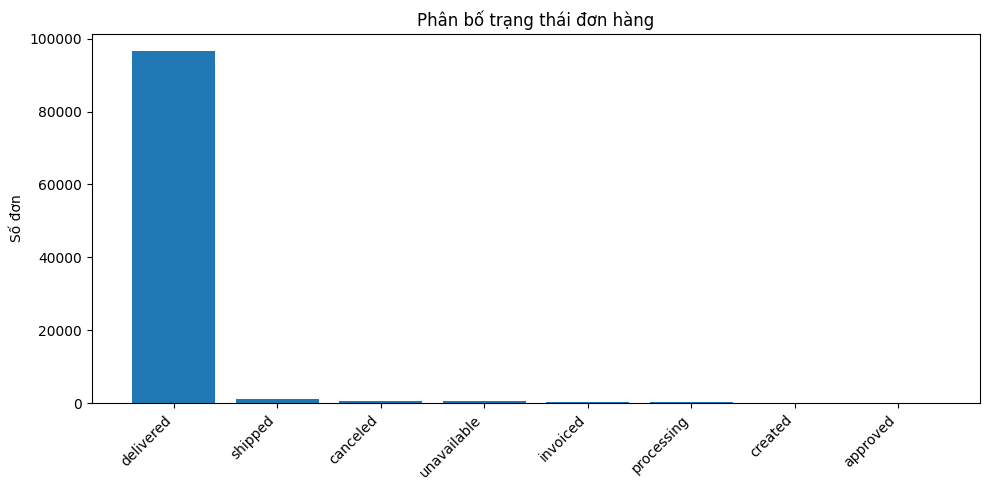

In [31]:
order_status_df = (
    orders_base_eda["order_status"]
    .value_counts(dropna=False)
    .rename_axis("order_status")
    .reset_index(name="order_count")
)

display(order_status_df)

plt.figure(figsize=(10, 5))
plt.bar(order_status_df["order_status"], order_status_df["order_count"])
plt.xticks(rotation=45, ha="right")
plt.title("Phân bố trạng thái đơn hàng")
plt.ylabel("Số đơn")
plt.tight_layout()
plt.show()


## Cell 32 — Xu hướng số lượng đơn hàng theo tháng

Cell này phân tích seasonality theo tháng mua hàng.


,purchase_month_period,order_count
13,2017-11,7544
14,2017-12,5673
15,2018-01,7269
16,2018-02,6728
17,2018-03,7211
18,2018-04,6939
19,2018-05,6873
20,2018-06,6167
21,2018-07,6292
22,2018-08,6512


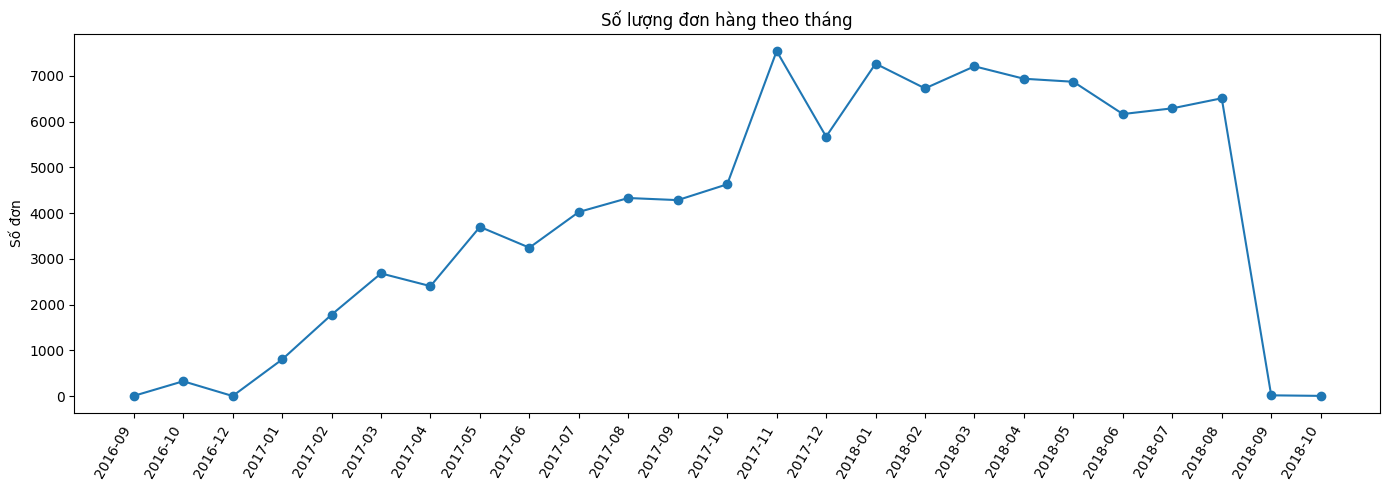

In [32]:
orders_per_month = (
    orders_base_eda
    .dropna(subset=["order_purchase_timestamp"])
    .assign(purchase_month_period=orders_base_eda["order_purchase_timestamp"].dt.to_period("M").astype(str))
    .groupby("purchase_month_period", as_index=False)
    .agg(order_count=("order_id", "nunique"))
    .sort_values("purchase_month_period")
)

display(orders_per_month.tail(12))

plt.figure(figsize=(14, 5))
plt.plot(orders_per_month["purchase_month_period"], orders_per_month["order_count"], marker="o")
plt.xticks(rotation=60, ha="right")
plt.title("Số lượng đơn hàng theo tháng")
plt.ylabel("Số đơn")
plt.tight_layout()
plt.show()


## Cell 33 — Phân bố đơn hàng theo ngày trong tuần

Cell này xem khách có xu hướng mua vào ngày nào nhiều hơn.


,weekday,order_count
0,Mon,16196
1,Tue,15963
2,Wed,15552
3,Thu,14761
4,Fri,14122
5,Sat,10887
6,Sun,11960


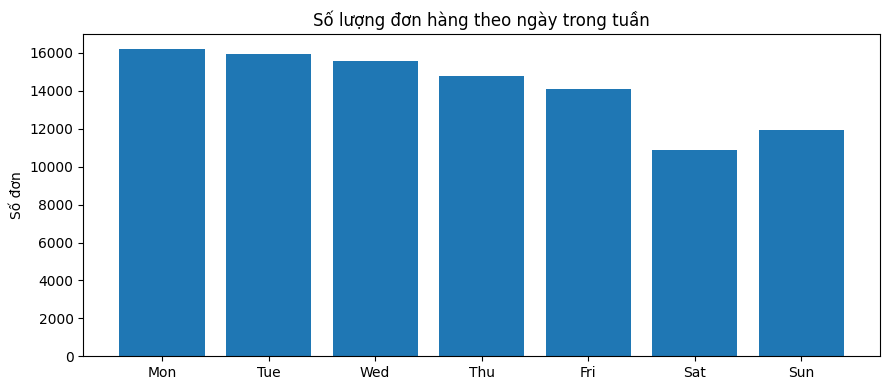

In [33]:
weekday_map = {
    0: "Mon", 1: "Tue", 2: "Wed", 3: "Thu", 4: "Fri", 5: "Sat", 6: "Sun"
}
orders_by_weekday = (
    orders_base_eda["purchase_dayofweek"]
    .dropna()
    .map(weekday_map)
    .value_counts()
    .reindex(["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"])
    .reset_index()
)
orders_by_weekday.columns = ["weekday", "order_count"]

display(orders_by_weekday)

plt.figure(figsize=(9, 4))
plt.bar(orders_by_weekday["weekday"], orders_by_weekday["order_count"])
plt.title("Số lượng đơn hàng theo ngày trong tuần")
plt.ylabel("Số đơn")
plt.tight_layout()
plt.show()


## Cell 34 — Phân bố đơn hàng theo giờ

Cell này kiểm tra khung giờ mua hàng nổi bật.


,hour,order_count
0,0,2394
1,1,1170
2,2,510
3,3,272
4,4,206


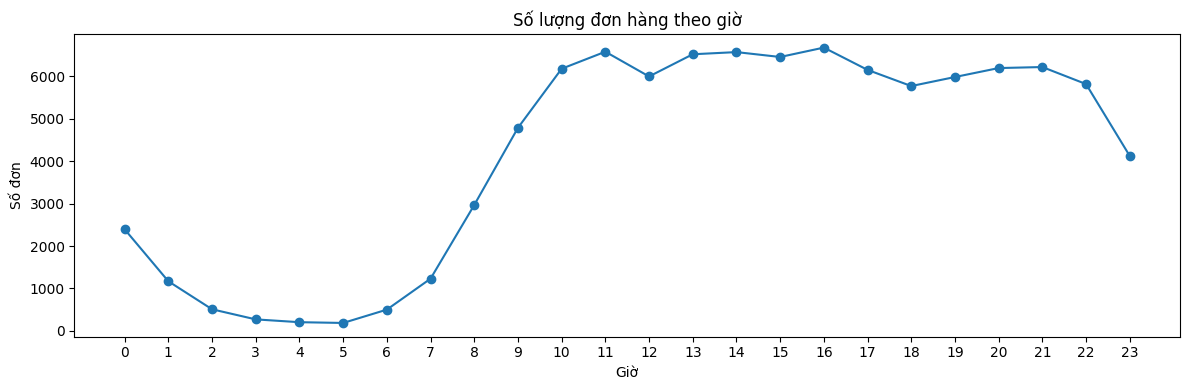

In [34]:
orders_by_hour = (
    orders_base_eda["purchase_hour"]
    .dropna()
    .astype(int)
    .value_counts()
    .sort_index()
    .reset_index()
)
orders_by_hour.columns = ["hour", "order_count"]

display(orders_by_hour.head())

plt.figure(figsize=(12, 4))
plt.plot(orders_by_hour["hour"], orders_by_hour["order_count"], marker="o")
plt.xticks(range(0, 24, 1))
plt.title("Số lượng đơn hàng theo giờ")
plt.xlabel("Giờ")
plt.ylabel("Số đơn")
plt.tight_layout()
plt.show()


## Cell 35 — Thống kê mô tả ở mức đơn hàng

Cell này tổng hợp một số thống kê mô tả quan trọng ở grain đơn hàng:
- giá trị thanh toán,
- số item,
- installment,
- thời gian giao hàng.


In [35]:
order_level_summary_df = pd.DataFrame([{
    "payment_value_mean": round(orders_base_eda["payment_value_sum"].mean(), 2),
    "payment_value_median": round(orders_base_eda["payment_value_sum"].median(), 2),
    "item_count_mean": round(orders_base_eda["item_count"].mean(), 2),
    "installments_mean": round(orders_base_eda["payment_installments_max"].mean(), 2),
    "delivery_time_days_mean": round(orders_base_eda["delivery_time_days"].mean(), 2),
}])

display(order_level_summary_df)


,payment_value_mean,payment_value_median,item_count_mean,installments_mean,delivery_time_days_mean
0,160.99,105.29,1.14,2.93,12.56


## Cell 36 — Top danh mục sản phẩm theo số lượng đơn hàng

Cell này cho biết nhóm danh mục nào xuất hiện nhiều nhất ở order-level.


,main_category,order_count
0,bed_bath_table,9384
1,health_beauty,8810
2,sports_leisure,7668
3,computers_accessories,6679
4,furniture_decor,6350
5,housewares,5811
6,watches_gifts,5584
7,telephony,4177
8,auto,3891
9,toys,3841


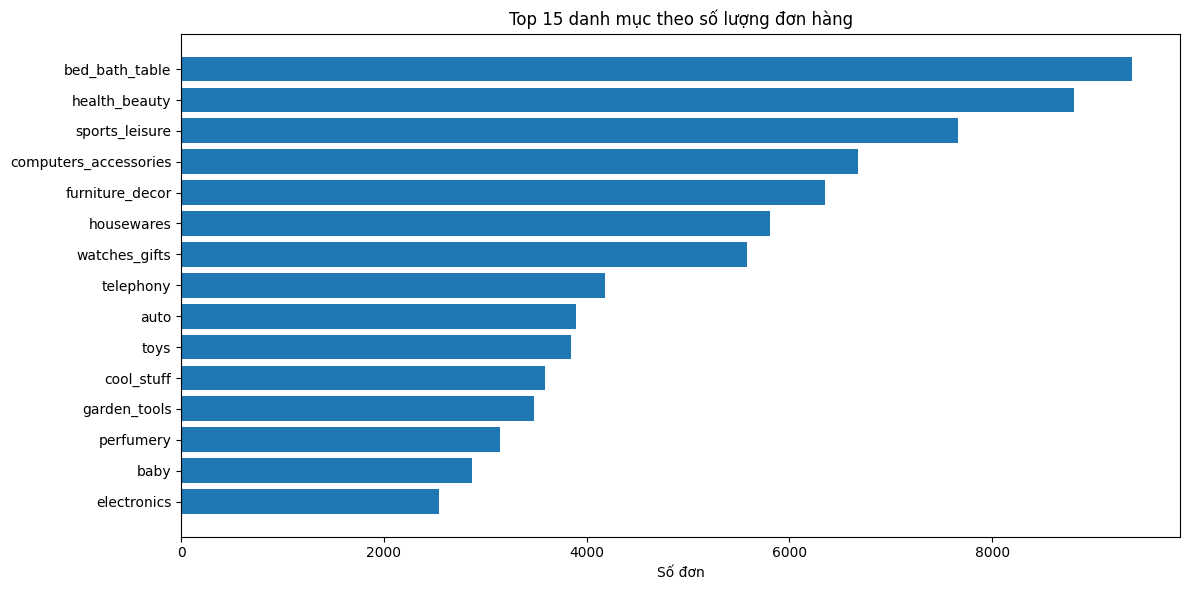

In [36]:
top_categories_df = (
    orders_base_eda["main_category"]
    .fillna("unknown")
    .value_counts()
    .head(15)
    .reset_index()
)
top_categories_df.columns = ["main_category", "order_count"]

display(top_categories_df)

plt.figure(figsize=(12, 6))
plt.barh(top_categories_df["main_category"], top_categories_df["order_count"])
plt.gca().invert_yaxis()
plt.title("Top 15 danh mục theo số lượng đơn hàng")
plt.xlabel("Số đơn")
plt.tight_layout()
plt.show()


## Cell 37 — Top bang (state) theo số lượng đơn hàng

Cell này phân tích phân bố đơn hàng theo state của khách hàng.


,customer_state,order_count
0,SP,41746
1,RJ,12852
2,MG,11635
3,RS,5466
4,PR,5045
5,SC,3637
6,BA,3380
7,DF,2140
8,ES,2033
9,GO,2020


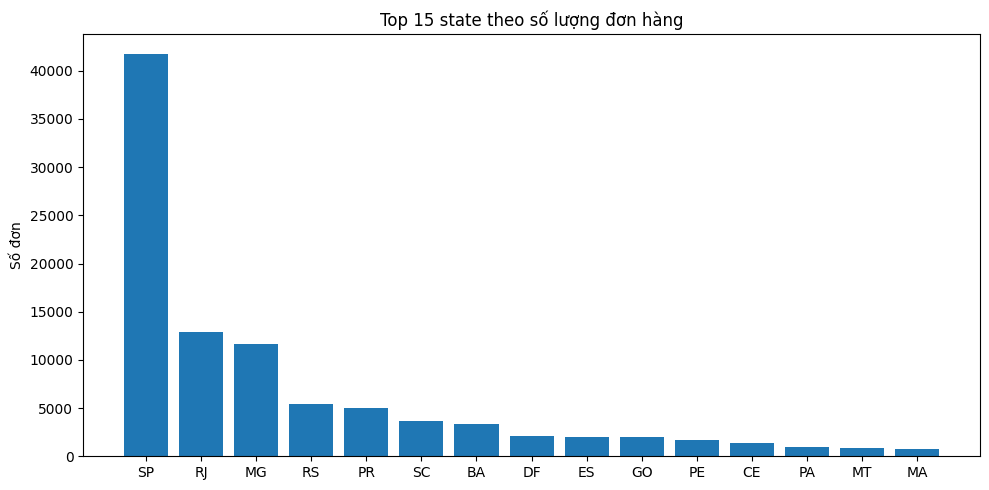

In [37]:
top_states_df = (
    orders_base_eda["customer_state"]
    .fillna("unknown")
    .value_counts()
    .head(15)
    .reset_index()
)
top_states_df.columns = ["customer_state", "order_count"]

display(top_states_df)

plt.figure(figsize=(10, 5))
plt.bar(top_states_df["customer_state"], top_states_df["order_count"])
plt.title("Top 15 state theo số lượng đơn hàng")
plt.ylabel("Số đơn")
plt.tight_layout()
plt.show()


## Cell 38 — Phân bố điểm đánh giá `review_score`

Cell này cho biết khách hàng đang cho điểm review như thế nào.


,review_score,count
0,1,11366
1,2,3129
2,3,8133
3,4,19044
4,5,57001


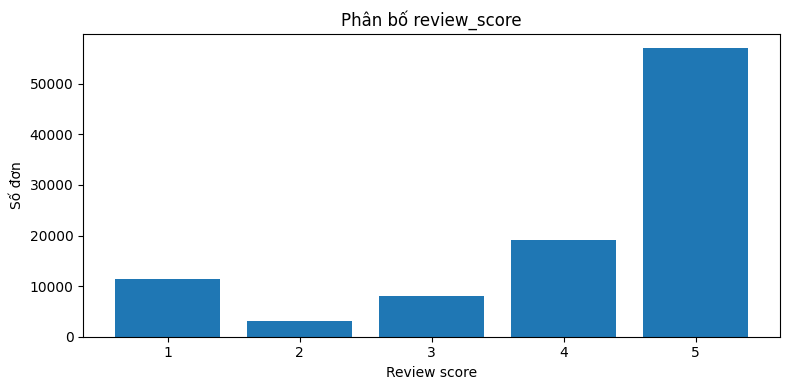

In [38]:
review_distribution_df = (
    orders_base_eda["review_score"]
    .dropna()
    .astype(int)
    .value_counts()
    .sort_index()
    .reset_index()
)
review_distribution_df.columns = ["review_score", "count"]

display(review_distribution_df)

plt.figure(figsize=(8, 4))
plt.bar(review_distribution_df["review_score"].astype(str), review_distribution_df["count"])
plt.title("Phân bố review_score")
plt.xlabel("Review score")
plt.ylabel("Số đơn")
plt.tight_layout()
plt.show()


## Cell 39 — Review score theo tình trạng giao trễ

Cell này kiểm tra một insight business quan trọng:
- giao trễ có làm điểm review giảm hay không.


In [39]:
review_vs_late_df = (
    orders_base_eda
    .dropna(subset=["review_score", "is_late_delivery"])
    .groupby("is_late_delivery", as_index=False)
    .agg(
        avg_review_score=("review_score", "mean"),
        order_count=("order_id", "nunique"),
    )
)

review_vs_late_df["is_late_delivery"] = review_vs_late_df["is_late_delivery"].map({0: "On time", 1: "Late"})
display(review_vs_late_df)


,is_late_delivery,avg_review_score,order_count
0,On time,4.294020,88171
1,Late,2.565331,7661


## Cell 40 — Review score theo state

Cell này xem sự khác biệt chất lượng trải nghiệm giữa các state lớn.


In [40]:
review_by_state_df = (
    orders_base_eda
    .dropna(subset=["customer_state", "review_score"])
    .groupby("customer_state", as_index=False)
    .agg(
        avg_review_score=("review_score", "mean"),
        order_count=("order_id", "nunique"),
    )
)

review_by_state_df = review_by_state_df[review_by_state_df["order_count"] >= 100].sort_values("order_count", ascending=False).head(15)
display(review_by_state_df)


,customer_state,avg_review_score,order_count
25,SP,4.173274,41472
18,RJ,3.877118,12687
10,MG,4.135364,11554
22,RS,4.132280,5443
17,PR,4.181311,5019
23,SC,4.073982,3609
4,BA,3.860778,3340
6,DF,4.063910,2128
8,GO,4.042850,2007
7,ES,4.037388,2006


## Cell 41 — Tương quan số giữa các feature order-level chính

Cell này tạo correlation matrix cho các feature numeric quan trọng ở mức order-level.


,review_score,item_count,unique_products,unique_sellers,price_sum,freight_value_sum,price_mean,payment_value_sum,basket_value,approval_time_hours,purchase_to_carrier_days,delivery_time_days,shipping_time_days,delivery_delay_days,review_comment_length,review_response_hours
review_score,1.000,-0.115,-0.097,-0.107,-0.039,-0.088,-0.012,-0.049,-0.046,-0.023,-0.157,-0.334,-0.300,-0.267,-0.389,0.007
item_count,-0.115,1.000,0.471,0.282,0.153,0.437,-0.058,0.189,0.189,0.025,0.033,-0.019,-0.034,-0.032,0.078,-0.000
unique_products,-0.097,0.471,1.000,0.593,0.061,0.195,-0.037,0.078,0.078,0.003,-0.008,-0.030,-0.028,-0.048,0.068,-0.000
unique_sellers,-0.107,0.282,0.593,1.000,0.041,0.130,-0.021,0.053,0.052,0.005,-0.028,-0.041,-0.031,-0.059,0.068,0.003
price_sum,-0.039,0.153,0.061,0.041,1.000,0.413,0.933,0.996,0.996,0.023,0.075,0.056,0.030,-0.014,0.059,-0.001
freight_value_sum,-0.088,0.437,0.195,0.130,0.413,1.000,0.302,0.493,0.493,0.040,0.095,0.167,0.144,-0.050,0.069,0.002
price_mean,-0.012,-0.058,-0.037,-0.021,0.933,0.302,1.000,0.921,0.921,0.013,0.068,0.060,0.038,-0.007,0.045,-0.001
payment_value_sum,-0.049,0.189,0.078,0.053,0.996,0.493,0.921,1.000,1.000,0.021,0.081,0.070,0.043,-0.018,0.065,0.000
basket_value,-0.046,0.189,0.078,0.052,0.996,0.493,0.921,1.000,1.000,0.026,0.081,0.070,0.042,-0.018,0.063,-0.001
approval_time_hours,-0.023,0.025,0.003,0.005,0.023,0.040,0.013,0.021,0.026,1.000,0.193,0.080,0.010,0.038,0.010,0.000


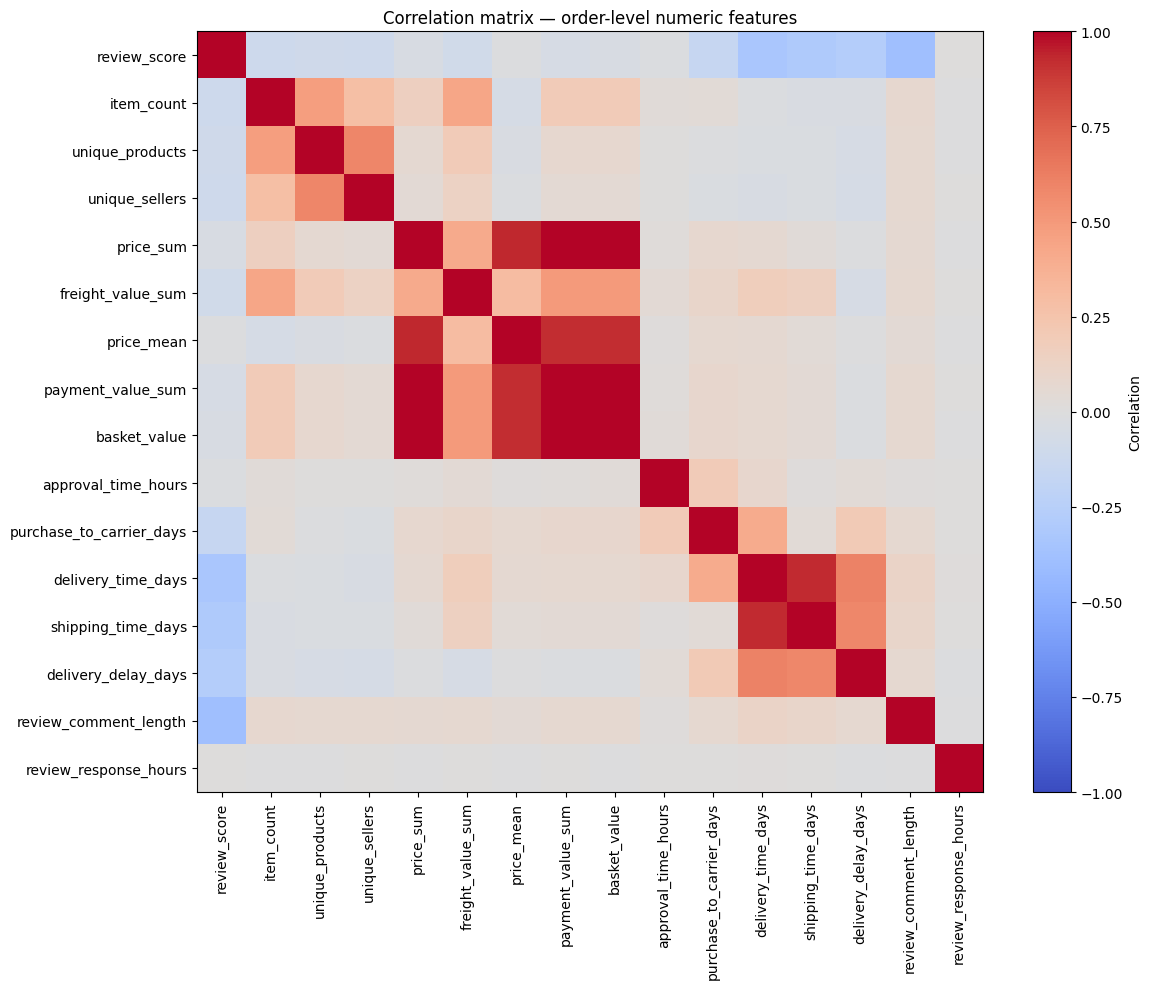

In [41]:
corr_features = [
    "review_score",
    "item_count",
    "unique_products",
    "unique_sellers",
    "price_sum",
    "freight_value_sum",
    "price_mean",
    "payment_value_sum",
    "basket_value",
    "approval_time_hours",
    "purchase_to_carrier_days",
    "delivery_time_days",
    "shipping_time_days",
    "delivery_delay_days",
    "review_comment_length",
    "review_response_hours",
]

corr_df = orders_base_eda[corr_features].apply(pd.to_numeric, errors="coerce").corr(numeric_only=True)
display(corr_df.round(3))

plt.figure(figsize=(12, 10))
plt.imshow(corr_df, cmap="coolwarm", aspect="auto", vmin=-1, vmax=1)
plt.xticks(range(len(corr_df.columns)), corr_df.columns, rotation=90)
plt.yticks(range(len(corr_df.columns)), corr_df.columns)
plt.colorbar(label="Correlation")
plt.title("Correlation matrix — order-level numeric features")
plt.tight_layout()
plt.show()


## Cell 42 — Top cặp tương quan mạnh nhất (lọc cặp trùng)

Cell này rút gọn correlation matrix thành các cặp đáng chú ý hơn để dễ viết nhận xét.


In [42]:
corr_pairs = corr_df.unstack().reset_index()
corr_pairs.columns = ["feature_1", "feature_2", "correlation"]

corr_pairs = corr_pairs[corr_pairs["feature_1"] < corr_pairs["feature_2"]].copy()
corr_pairs["abs_corr"] = corr_pairs["correlation"].abs()

top_corr_pairs_df = corr_pairs.sort_values("abs_corr", ascending=False).head(20)
display(top_corr_pairs_df[["feature_1", "feature_2", "correlation"]].reset_index(drop=True))


,feature_1,feature_2,correlation
0,basket_value,payment_value_sum,0.999987
1,basket_value,price_sum,0.995991
2,payment_value_sum,price_sum,0.995970
3,price_mean,price_sum,0.933169
4,delivery_time_days,shipping_time_days,0.926392
5,basket_value,price_mean,0.921212
6,payment_value_sum,price_mean,0.921196
7,delivery_delay_days,delivery_time_days,0.607221
8,unique_products,unique_sellers,0.592784
9,delivery_delay_days,shipping_time_days,0.581250


## Cell 43 — Tạo RFM chỉ trên đơn `delivered`

Cell này cố ý chỉ dùng `delivered` orders để tránh mâu thuẫn logic:
- Recency chỉ có ý nghĩa rõ nhất trên giao dịch hoàn tất;
- Frequency là số đơn hoàn tất của khách;
- Monetary là tổng thanh toán của các đơn hoàn tất.


In [43]:
delivered_df = orders_base_eda[orders_base_eda["order_status"] == "delivered"].copy()
reference_date = delivered_df["order_purchase_timestamp"].max() + pd.Timedelta(days=1)

rfm_df = (
    delivered_df
    .groupby("customer_unique_id", as_index=False)
    .agg(
        recency_days=("order_purchase_timestamp", lambda x: (reference_date - x.max()).days),
        frequency_orders=("order_id", "nunique"),
        monetary_value=("payment_value_sum", "sum"),
    )
)

display(rfm_df.head())
print("rfm_df shape:", rfm_df.shape)


,customer_unique_id,recency_days,frequency_orders,monetary_value
0,0000366f3b9a7992bf8c76cfdf3221e2,112,1,141.90
1,0000b849f77a49e4a4ce2b2a4ca5be3f,115,1,27.19
2,0000f46a3911fa3c0805444483337064,537,1,86.22
3,0000f6ccb0745a6a4b88665a16c9f078,321,1,43.62
4,0004aac84e0df4da2b147fca70cf8255,288,1,196.89


rfm_df shape: (93358, 4)


## Cell 44 — Thống kê mô tả RFM bằng `.describe()`

Cell này tạo bảng mô tả RFM theo đúng yêu cầu báo cáo.


In [44]:
rfm_describe_df = rfm_df[["recency_days", "frequency_orders", "monetary_value"]].describe().T.reset_index().rename(columns={"index": "metric"})
display(rfm_describe_df)


,metric,count,mean,std,min,25%,50%,75%,max
0,recency_days,93358.0,237.941773,152.591453,1.0,114.0000,219.00,346.0000,714.00
1,frequency_orders,93358.0,1.033420,0.209097,1.0,1.0000,1.00,1.0000,15.00
2,monetary_value,93358.0,165.197003,226.314012,0.0,63.0525,107.78,182.5575,13664.08


## Cell 45 — Biểu đồ phân bố RFM

Cell này trực quan hóa phân phối của 3 thành phần RFM.


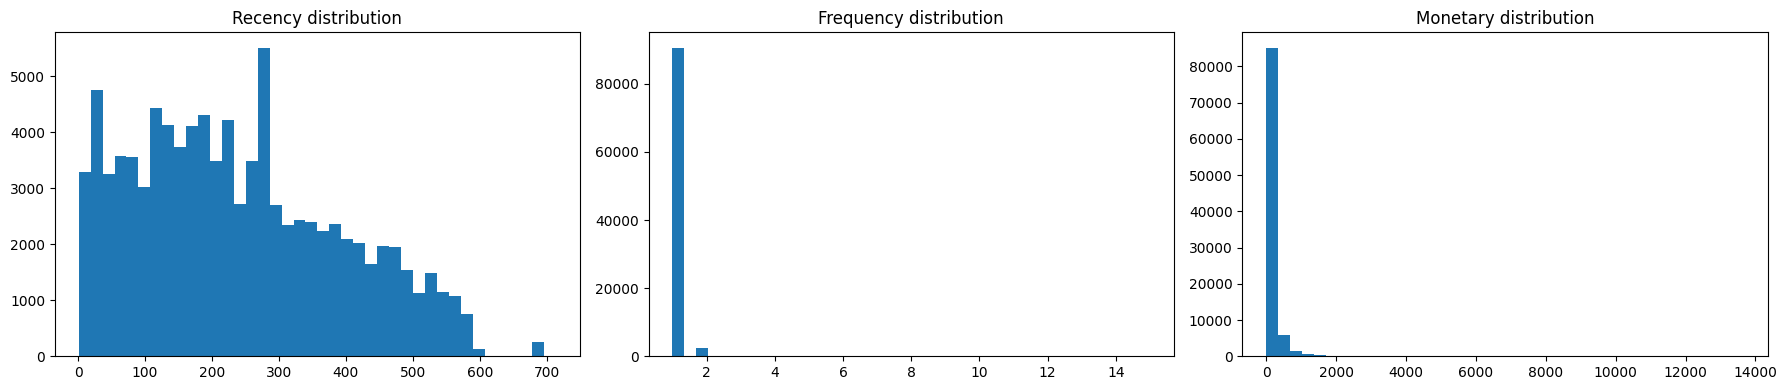

In [45]:
fig, axes = plt.subplots(1, 3, figsize=(18, 4))

axes[0].hist(rfm_df["recency_days"].dropna(), bins=40)
axes[0].set_title("Recency distribution")

axes[1].hist(rfm_df["frequency_orders"].dropna(), bins=40)
axes[1].set_title("Frequency distribution")

axes[2].hist(rfm_df["monetary_value"].dropna(), bins=40)
axes[2].set_title("Monetary distribution")

plt.tight_layout()
plt.show()


## Cell 46 — Top khách hàng chi tiêu cao nhất

Cell này giúp nhận diện tail behavior ở phần Monetary.


In [46]:
top_monetary_customers_df = rfm_df.sort_values("monetary_value", ascending=False).head(15)
display(top_monetary_customers_df)


,customer_unique_id,recency_days,frequency_orders,monetary_value
3724,0a0a92112bd4c708ca5fde585afaa872,334,1,13664.08
79636,da122df9eeddfedc1dc1f5349a1a690c,515,2,7571.63
43168,763c8b1c9c68a0229c42c9fc6f662b93,46,1,7274.88
80463,dc4802a71eae9be1dd28f5d788ceb526,563,1,6929.31
25436,459bef486812aa25204be022145caa62,35,1,6922.21
93081,ff4159b92c40ebe40454e3e6a7c35ed6,462,1,6726.66
23411,4007669dec559734d6f53e029e360987,279,1,6081.54
87148,eebb5dda148d3893cdaf5b5ca3040ccb,498,1,4764.34
26640,48e1ac109decbb87765a3eade6854098,69,1,4681.78
73127,c8460e4251689ba205045f3ea17884a1,22,4,4655.91


## Cell 47 — Tổng hợp insight EDA quan trọng

Cell này gom các kết luận định lượng quan trọng nhất để phục vụ viết báo cáo và thuyết trình.


In [47]:
monthly_peak = orders_per_month.sort_values("order_count", ascending=False).iloc[0]
monthly_low = orders_per_month.sort_values("order_count", ascending=True).iloc[0]
top_weekday = orders_by_weekday.sort_values("order_count", ascending=False).iloc[0]
top_hour = orders_by_hour.sort_values("order_count", ascending=False).iloc[0]
top_category = top_categories_df.iloc[0]
top_state = top_states_df.iloc[0]

eda_key_findings_df = pd.DataFrame([
    {"finding": "Month with highest orders", "value": f"{monthly_peak['purchase_month_period']} ({monthly_peak['order_count']})"},
    {"finding": "Month with lowest orders", "value": f"{monthly_low['purchase_month_period']} ({monthly_low['order_count']})"},
    {"finding": "Weekday with highest orders", "value": f"{top_weekday['weekday']} ({top_weekday['order_count']})"},
    {"finding": "Hour with highest orders", "value": f"{int(top_hour['hour'])}h ({top_hour['order_count']})"},
    {"finding": "Top category by orders", "value": f"{top_category['main_category']} ({top_category['order_count']})"},
    {"finding": "Top state by orders", "value": f"{top_state['customer_state']} ({top_state['order_count']})"},
])

display(eda_key_findings_df)


,finding,value
0,Month with highest orders,2017-11 (7544)
1,Month with lowest orders,2016-12 (1)
2,Weekday with highest orders,Mon (16196)
3,Hour with highest orders,16h (6675)
4,Top category by orders,bed_bath_table (9384)
5,Top state by orders,SP (41746)


## CHECK-IN — FILE 01: `01_eda_data_structure_check.ipynb`

### A. THIẾT LẬP BAN ĐẦU
- [x] Hoàn thành import thư viện cần dùng cho notebook EDA
- [x] Hoàn thành khai báo danh sách file raw bắt buộc
- [x] Hoàn thành hàm resolve đường dẫn dự án
- [x] Hoàn thành resolve `BASE_DIR`
- [x] Hoàn thành resolve `RAW_DIR`

---

### B. ĐỌC DỮ LIỆU
- [x] Hoàn thành đọc **đủ 9 bảng CSV** của bộ dữ liệu Olist
- [x] Hoàn thành tạo bảng tổng quan kích thước 9 bảng
- [x] Hoàn thành tạo từ điển `dfs` để thao tác thống nhất giữa các DataFrame
- [x] Hoàn thành xem tổng quát nhanh từng bảng

---

### C. KHẢO SÁT CẤU TRÚC DỮ LIỆU
- [x] Hoàn thành kiểm tra `.info()` ở mức tóm tắt cho từng bảng
- [x] Hoàn thành thống kê dtype cho từng bảng
- [x] Hoàn thành tạo bảng mô tả logic quan hệ giữa các bảng
- [x] Hoàn thành vẽ **ERD logic** ở mức notebook

---

### D. CHUẨN HÓA DỮ LIỆU BAN ĐẦU
- [x] Hoàn thành chuẩn hóa các cột thời gian sang `datetime`
- [x] Hoàn thành chuẩn hóa `zip prefix`
- [x] Hoàn thành kiểm tra duplicate toàn dòng cho các bảng
- [x] Hoàn thành kiểm tra uniqueness của các khóa quan trọng

---

### E. PHÂN TÍCH MISSING VALUES
- [x] Hoàn thành kiểm tra missing values theo từng bảng
- [x] Hoàn thành tổng hợp top cột missing quan trọng trong toàn dataset
- [x] Hoàn thành vẽ biểu đồ top missing columns
- [x] Hoàn thành drill-down riêng các bảng missing quan trọng:
  - `order_reviews`
  - `products`
  - `orders`

---

### F. KIỂM TRA QUAN HỆ / COVERAGE KHÓA JOIN
- [x] Hoàn thành kiểm tra coverage khóa join giữa các bảng
- [x] Hoàn thành tạo helper cho phần order-level EDA base
- [x] Hoàn thành tạo hàm `safe_mode`

---

### G. TẠO BẢNG TRUNG GIAN ĐỂ PHỤC VỤ EDA ORDER-LEVEL
- [x] Hoàn thành tạo `geo_by_zip`
- [x] Hoàn thành tạo `products_en`
- [x] Hoàn thành enrich `customers`
- [x] Hoàn thành enrich `sellers`
- [x] Hoàn thành aggregate `order_items` ở mức đơn hàng
- [x] Hoàn thành aggregate `order_payments` về mức đơn hàng
- [x] Hoàn thành aggregate `order_reviews` về mức đơn hàng

---

### H. TẠO MASTER EDA TABLE
- [x] Hoàn thành tạo `orders_base_eda`
- [x] Hoàn thành đưa đủ 9 bảng đi qua luồng tạo `orders_base_eda`
- [x] Hoàn thành kiểm tra grain sau merge của `orders_base_eda`
- [x] Hoàn thành kiểm tra missing values trên `orders_base_eda`
- [x] Hoàn thành xử lý missing tối thiểu để phục vụ EDA

---

### I. FEATURE ENGINEERING PHỤC VỤ EDA
- [x] Hoàn thành sinh feature thời gian
- [x] Hoàn thành sinh feature giao hàng
- [x] Hoàn thành sinh feature basket
- [x] Hoàn thành tạo snapshot nhanh của `orders_base_eda`

---

### J. EDA Ở MỨC ORDER-LEVEL
- [x] Hoàn thành phân bố trạng thái đơn hàng
- [x] Hoàn thành xu hướng số lượng đơn hàng theo tháng
- [x] Hoàn thành phân bố đơn hàng theo ngày trong tuần
- [x] Hoàn thành phân bố đơn hàng theo giờ
- [x] Hoàn thành thống kê mô tả ở mức đơn hàng
- [x] Hoàn thành thống kê top danh mục sản phẩm theo số lượng đơn hàng
- [x] Hoàn thành thống kê top bang (`state`) theo số lượng đơn hàng

---

### K. PHÂN TÍCH REVIEW
- [x] Hoàn thành phân bố điểm đánh giá `review_score`
- [x] Hoàn thành phân tích `review_score` theo tình trạng giao trễ
- [x] Hoàn thành phân tích `review_score` theo `state`

---

### L. TƯƠNG QUAN / CORRELATION
- [x] Hoàn thành tạo ma trận tương quan số giữa các feature order-level chính
- [x] Hoàn thành hiển thị heatmap / biểu đồ tương quan
- [x] Hoàn thành tạo bảng top cặp tương quan mạnh nhất

---

### M. RFM ANALYSIS TRONG NOTEBOOK EDA
- [x] Hoàn thành tạo `rfm_df` chỉ trên đơn `delivered`
- [x] Hoàn thành tính:
  - `recency_days`
  - `frequency_orders`
  - `monetary_value`
- [x] Hoàn thành thống kê mô tả RFM bằng `.describe()`
- [x] Hoàn thành vẽ biểu đồ phân bố RFM
- [x] Hoàn thành thống kê top khách hàng chi tiêu cao nhất

---

### N. INSIGHT TỔNG HỢP
- [x] Hoàn thành tổng hợp insight EDA quan trọng
- [x] Hoàn thành kết luận notebook EDA
- [x] Hoàn thành ghi rõ phạm vi ảnh hưởng của notebook đối với các bước downstream

---

### O. KẾT LUẬN CHECK-IN
- [x] Hoàn thành phần **Đọc và khảo sát 9 bảng dữ liệu**
- [x] Hoàn thành phần **Kiểm tra cấu trúc dữ liệu**
- [x] Hoàn thành phần **ERD và quan hệ giữa các bảng**
- [x] Hoàn thành phần **Duplicate / uniqueness / missing values**
- [x] Hoàn thành phần **Coverage khóa join**
- [x] Hoàn thành phần **Tạo bảng EDA order-level**
- [x] Hoàn thành phần **Feature engineering phục vụ EDA**
- [x] Hoàn thành phần **Phân tích phân bố đơn hàng**
- [x] Hoàn thành phần **Phân tích review**
- [x] Hoàn thành phần **Correlation analysis**
- [x] Hoàn thành phần **RFM analysis**
- [x] Hoàn thành phần **Tổng hợp insight EDA**

### Kết luận cuối:
Notebook `01_eda_data_structure_check.ipynb` đã **hoàn thành** toàn bộ các hạng mục chính thuộc phạm vi **EDA, Data Structure Check, Relationship Audit và RFM EDA** của riêng file này.